In [5]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [6]:
red = pd.read_csv('data/winequality-red.csv', sep=';')
white = pd.read_csv('data/winequality-white.csv', sep=';')

red['is_red'] = 1
white['is_red'] = 0

df = pd.concat([red, white], ignore_index=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [7]:
print(df.isnull().sum())
df.describe()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
is_red                  0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [ ]:
#dropping quality vals because were predicting this

X = df.drop(columns=['quality']).values   
y = df['quality'].values

m = len(df)
idx = np.random.permutation(m)

train_size = int(0.70 * m)
val_size = int(0.15 * m)

train_idx = idx[:train_size]
val_idx = idx[train_size:train_size + val_size]
test_idx = idx[train_size + val_size:]

X_train_raw = X[train_idx]
y_train = y[train_idx]

X_val_raw = X[val_idx]
y_val = y[val_idx]

X_test_raw = X[test_idx]
y_test = y[test_idx]

mean = np.mean(X_train_raw, axis=0)
std = np.std(X_train_raw, axis=0)

X_train_scaled = (X_train_raw - mean) / std
X_val_scaled = (X_val_raw - mean) / std
X_test_scaled = (X_test_raw - mean) / std

X_train = np.hstack([np.ones((len(X_train_scaled), 1)), X_train_scaled])
X_val = np.hstack([np.ones((len(X_val_scaled), 1)), X_val_scaled])
X_test = np.hstack([np.ones((len(X_test_scaled), 1)), X_test_scaled])

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(4547, 13) (4547,)
(974, 13) (974,)
(976, 13) (976,)


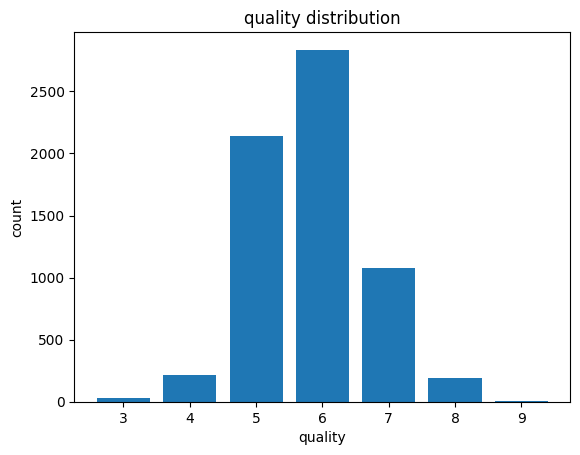

In [9]:
plt.figure()
plt.hist(df['quality'], bins=range(3, 11), align='left', rwidth=0.8)
plt.xlabel('quality')
plt.ylabel('count')
plt.title('quality distribution')
plt.show()

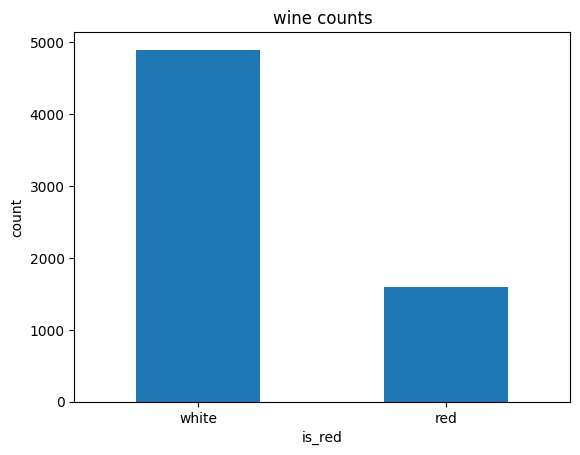

In [10]:
df['is_red'].value_counts().plot(kind='bar')
plt.xticks([0, 1], ['white', 'red'], rotation=0)
plt.ylabel('count')
plt.title('wine counts')
plt.show()

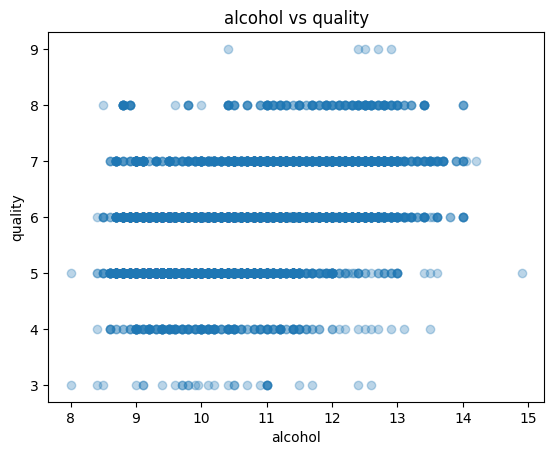

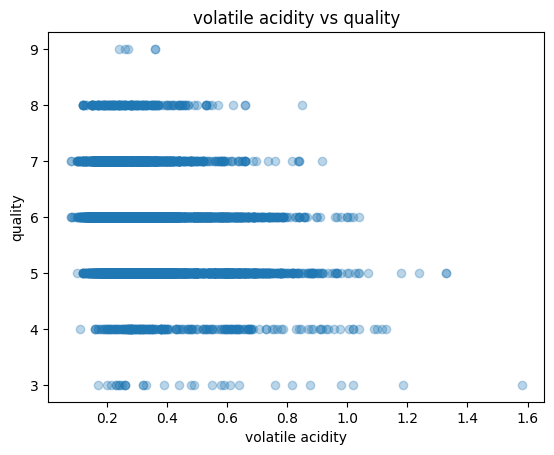

In [11]:
plt.figure()
plt.scatter(df['alcohol'], df['quality'], alpha=0.3)
plt.xlabel('alcohol')
plt.ylabel('quality')
plt.title('alcohol vs quality')
plt.show()

plt.figure()
plt.scatter(df['volatile acidity'], df['quality'], alpha=0.3)
plt.xlabel('volatile acidity')
plt.ylabel('quality')
plt.title('volatile acidity vs quality')
plt.show()

In [12]:
def compute_mse(X, y, w):
    y_hat = X @ w
    return np.mean((y - y_hat) ** 2)

lr = 0.01
epochs = 2000

m_train = len(X_train)
n_features = X_train.shape[1]

np.random.seed(42)
w_batch = np.random.randn(n_features) * 0.01

for epoch in range(epochs):
    y_hat = X_train @ w_batch
    grad = (2 / m_train) * (X_train.T @ (y_hat - y_train))
    w_batch = w_batch - lr * grad

print("Batch GD:")
print("train mse:", compute_mse(X_train, y_train, w_batch))
print("val mse:  ", compute_mse(X_val, y_val, w_batch))
print("test mse: ", compute_mse(X_test, y_test, w_batch))

Batch GD:
train mse: 0.5402248926086021
val mse:   0.56060407067157
test mse:  0.4989383778677832


In [13]:
batch_size = 64

np.random.seed(42)
w_mini = np.random.randn(n_features) * 0.01

for epoch in range(epochs):
    idx = np.random.choice(m_train, size=batch_size, replace=False)
    X_b = X_train[idx]
    y_b = y_train[idx]
    
    y_hat = X_b @ w_mini
    grad = (2 / batch_size) * (X_b.T @ (y_hat - y_b))
    w_mini = w_mini - lr * grad

print("Mini-batch GD:")
print("train mse:", compute_mse(X_train, y_train, w_mini))
print("val mse:  ", compute_mse(X_val, y_val, w_mini))
print("test mse: ", compute_mse(X_test, y_test, w_mini))

Mini-batch GD:
train mse: 0.5412039243092933
val mse:   0.5626129615650098
test mse:  0.5015392600490608


In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
best_alpha_l2 = None
best_val_mse = float('inf')

for a in alphas:
    np.random.seed(42)
    w = np.random.randn(n_features) * 0.01
    for epoch in range(epochs):
        y_hat = X_train @ w
        reg_grad = 2 * a * w
        reg_grad[0] = 0
        grad = (2 / m_train) * (X_train.T @ (y_hat - y_train)) + reg_grad
        w = w - lr * grad
    v_mse = compute_mse(X_val, y_val, w)
    print(f"alpha: {a}, val mse: {v_mse}")
    if v_mse < best_val_mse:
        best_val_mse = v_mse
        best_alpha_l2 = a

print("best alpha for L2:", best_alpha_l2)

In [ ]:
np.random.seed(42)
w_batch_l2 = np.random.randn(n_features) * 0.01
for epoch in range(epochs):
    y_hat = X_train @ w_batch_l2
    reg_grad = 2 * best_alpha_l2 * w_batch_l2
    reg_grad[0] = 0
    grad = (2 / m_train) * (X_train.T @ (y_hat - y_train)) + reg_grad
    w_batch_l2 = w_batch_l2 - lr * grad

print("Batch GD (L2):")
print("train mse:", compute_mse(X_train, y_train, w_batch_l2))
print("val mse:  ", compute_mse(X_val, y_val, w_batch_l2))
print("test mse: ", compute_mse(X_test, y_test, w_batch_l2))

np.random.seed(42)
w_mini_l2 = np.random.randn(n_features) * 0.01
for epoch in range(epochs):
    idx = np.random.choice(m_train, size=batch_size, replace=False)
    X_b = X_train[idx]
    y_b = y_train[idx]
    y_hat = X_b @ w_mini_l2
    reg_grad = 2 * best_alpha_l2 * w_mini_l2
    reg_grad[0] = 0
    grad = (2 / batch_size) * (X_b.T @ (y_hat - y_b)) + reg_grad
    w_mini_l2 = w_mini_l2 - lr * grad

print("\nMini-batch GD (L2):")
print("train mse:", compute_mse(X_train, y_train, w_mini_l2))
print("val mse:  ", compute_mse(X_val, y_val, w_mini_l2))
print("test mse: ", compute_mse(X_test, y_test, w_mini_l2))

In [ ]:
feature_names = ['bias'] + [c for c in df.columns if c != 'quality']
smallest_idx = np.argmin(np.abs(w_batch_l2[1:])) + 1
print("eliminated attribute:", feature_names[smallest_idx], "weight:", w_batch_l2[smallest_idx])

X_train_l2_red = np.delete(X_train, smallest_idx, axis=1)
X_val_l2_red = np.delete(X_val, smallest_idx, axis=1)
X_test_l2_red = np.delete(X_test, smallest_idx, axis=1)

np.random.seed(42)
w_l2_retrained = np.random.randn(X_train_l2_red.shape[1]) * 0.01
for epoch in range(epochs):
    y_hat = X_train_l2_red @ w_l2_retrained
    grad = (2 / m_train) * (X_train_l2_red.T @ (y_hat - y_train))
    w_l2_retrained = w_l2_retrained - lr * grad

print("\nRetrained on reduced set (Batch GD):")
print("train mse:", compute_mse(X_train_l2_red, y_train, w_l2_retrained))
print("val mse:  ", compute_mse(X_val_l2_red, y_val, w_l2_retrained))
print("test mse: ", compute_mse(X_test_l2_red, y_test, w_l2_retrained))